In [12]:
# ============================================================
# CELL 1 - Install
# ============================================================
!pip install ultralytics transformers -q

In [2]:
# ============================================================
# CELL 2 - Imports
# ============================================================
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from ultralytics import YOLO
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
from PIL import ImageDraw, ImageFont
import math
import colorsys

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using: cuda


In [3]:
# ============================================================
# CELL 3 - Load YOLO + CLIP
# ============================================================
# ── update this path ──
MODEL_PATH = "/kaggle/input/datasets/astitwarajawat/yolo-model/best.pt"

detector   = YOLO(MODEL_PATH)

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval().to(device)

print("YOLO + CLIP loaded!")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

YOLO + CLIP loaded!


In [22]:
# ============================================================
# CELL 4 - Load image
# ============================================================
IMAGE_PATH = "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/images/test/test_1043.jpg"  # update path

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f"Image shape: {img_rgb.shape}")

Image shape: (3264, 2448, 3)


Detected 152 objects


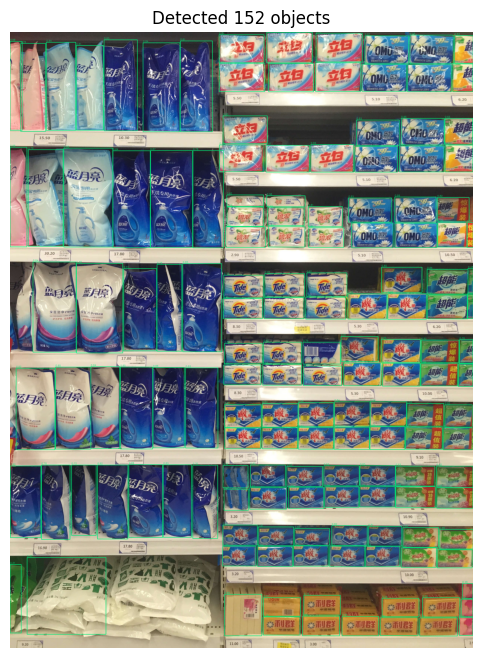

In [23]:
# ============================================================
# CELL 5 - Detect objects
# ============================================================
results = detector(img_rgb, conf=0.25, iou=0.45, verbose=False)[0]
boxes   = results.boxes.xyxy.cpu().numpy().astype(int)
confs   = results.boxes.conf.cpu().numpy()

print(f"Detected {len(boxes)} objects")

# Show detections
vis = img_rgb.copy()
for box, conf in zip(boxes, confs):
    x1, y1, x2, y2 = box
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,230,120), 2)
    cv2.putText(vis, f"{conf:.2f}", (x1, y1-4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,230,120), 1)

plt.figure(figsize=(16,8))
plt.imshow(vis)
plt.title(f"Detected {len(boxes)} objects")
plt.axis("off")
plt.show()

In [24]:
# ============================================================
# CELL 6 - Crop detections
# ============================================================
MIN_SIZE    = 20
crops       = []
valid_boxes = []

for box in boxes:
    x1, y1, x2, y2 = box
    if (x2-x1) < MIN_SIZE or (y2-y1) < MIN_SIZE:
        continue
    crops.append(img_rgb[y1:y2, x1:x2])
    valid_boxes.append(box)

print(f"{len(crops)} valid crops")

152 valid crops


In [25]:
# ============================================================
# CELL 7 - Extract CLIP embeddings
#
# What happens here:
# 1. Each crop is resized to 224x224
# 2. Passed through CLIP vision transformer (12 layers, 7x7 patches)
# 3. Output is a 512-dim vector
# 4. L2 normalized so cosine similarity = dot product
# ============================================================
BATCH_SIZE = 32  # process this many crops at once

def get_clip_embeddings(crops, batch_size=32):
    all_embeddings = []

    for i in range(0, len(crops), batch_size):
        batch      = crops[i : i+batch_size]
        pil_batch  = [Image.fromarray(c) for c in batch]

        inputs = processor(
            images=pil_batch,
            return_tensors="pt",
            padding=True
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            vision_out = clip_model.vision_model(
                pixel_values=inputs["pixel_values"]
            )
            # pooler_output = single vector summarizing the whole image
            embeddings = clip_model.visual_projection(
                vision_out.pooler_output
            )

        # L2 normalize — makes cosine similarity = dot product
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
        all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

embeddings = get_clip_embeddings(crops, BATCH_SIZE)
print(f"Embeddings shape: {embeddings.shape}")  # (n_crops, 512)

Embeddings shape: (152, 512)


In [26]:
# ============================================================
# CELL 8 - Compute cosine similarity matrix
#
# Since embeddings are L2 normalized:
# cosine_similarity(a, b) = dot(a, b)
# 1.0 = identical  |  0.0 = unrelated  |  -1.0 = opposite
# ============================================================
sim_matrix = embeddings @ embeddings.T  # shape: (n, n)

print(f"Similarity matrix: {sim_matrix.shape}")
print(f"Max similarity (excluding diagonal): {np.fill_diagonal(sim_matrix.copy(), 0) or sim_matrix.max():.3f}")
print(f"\nSample similarities (first 5 crops vs each other):")
for i in range(min(5, len(crops))):
    row = [f"{sim_matrix[i][j]:.2f}" for j in range(min(5, len(crops)))]
    print(f"  Crop {i}: {row}")

Similarity matrix: (152, 152)
Max similarity (excluding diagonal): 1.000

Sample similarities (first 5 crops vs each other):
  Crop 0: ['1.00', '0.74', '0.72', '0.77', '0.85']
  Crop 1: ['0.74', '1.00', '0.86', '0.83', '0.77']
  Crop 2: ['0.72', '0.86', '1.00', '0.80', '0.69']
  Crop 3: ['0.77', '0.83', '0.80', '1.00', '0.85']
  Crop 4: ['0.85', '0.77', '0.69', '0.85', '1.00']


In [35]:
# ============================================================
# CELL 9 - Cluster similar products with DBSCAN
#
# DBSCAN groups crops where cosine distance < eps
# cosine distance = 1 - cosine_similarity
# eps=0.3 means similarity > 0.7 to be in same group
#
# Tune eps:
#   lower eps (e.g. 0.15) → stricter, more groups
#   higher eps (e.g. 0.40) → looser, fewer groups
# ============================================================
EPS      = 0.07   # ← tune this (cosine distance threshold)
MIN_SAMP = 2      # min crops to form a group

clustering = DBSCAN(
    eps=EPS,
    min_samples=MIN_SAMP,
    metric="cosine"
).fit(embeddings)

labels      = clustering.labels_
n_groups    = len(set(labels)) - (1 if -1 in labels else 0)
n_noise     = list(labels).count(-1)
group_sizes = {}
for l in labels:
    if l != -1:
        group_sizes[l] = group_sizes.get(l, 0) + 1

print(f"Groups found:     {n_groups}")
print(f"Unmatched crops:  {n_noise}")
print(f"\nGroup sizes (sorted):")
for gid, size in sorted(group_sizes.items(), key=lambda x: -x[1]):
    print(f"  Group {gid}: {size} items")

Groups found:     9
Unmatched crops:  48

Group sizes (sorted):
  Group 0: 66 items
  Group 4: 10 items
  Group 1: 6 items
  Group 3: 6 items
  Group 2: 5 items
  Group 5: 4 items
  Group 6: 3 items
  Group 7: 2 items
  Group 8: 2 items


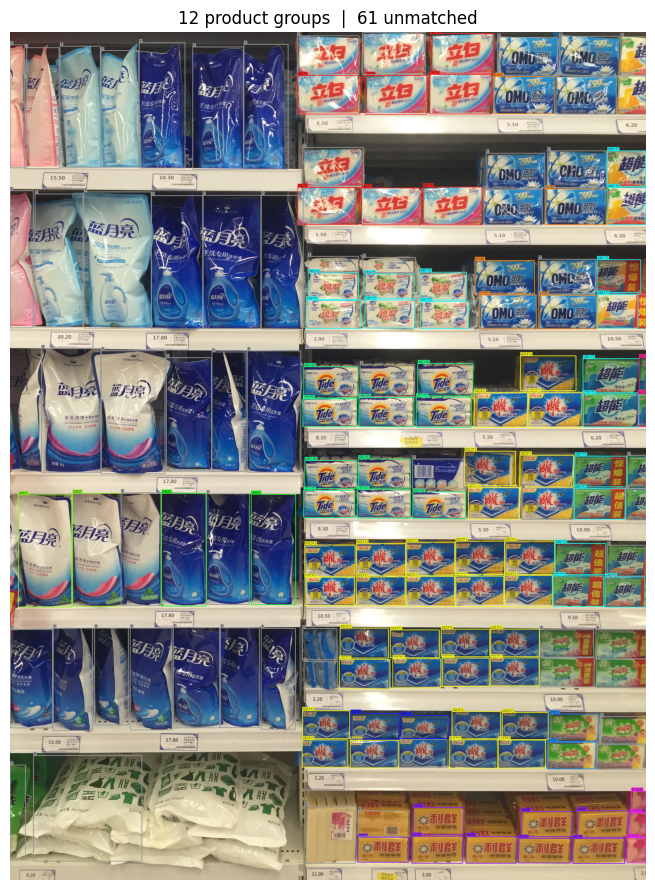

In [33]:
# ============================================================
# CELL 10 - Draw groups on original image
# ============================================================
def hsv_color(i, n):
    r, g, b = colorsys.hsv_to_rgb(i/max(n,1), 0.85, 0.95)
    return (int(r*255), int(g*255), int(b*255))

n_groups    = len(set(l for l in labels if l != -1))
group_color = {gid: hsv_color(i, n_groups)
               for i, gid in enumerate(set(l for l in labels if l != -1))}
group_color[-1] = (150, 150, 150)  # gray for unmatched

output = img_rgb.copy()
for box, label in zip(valid_boxes, labels):
    x1, y1, x2, y2 = box
    color = group_color[label]
    count = group_sizes.get(label, 1)

    cv2.rectangle(output, (x1,y1), (x2,y2), color, 2)

    tag = f"G{label}({count})" if label != -1 else "?"
    (tw, th), _ = cv2.getTextSize(tag, cv2.FONT_HERSHEY_SIMPLEX, 0.38, 1)
    cv2.rectangle(output, (x1, y1-th-5), (x1+tw+4, y1), color, -1)
    cv2.putText(output, tag, (x1+2, y1-3),
                cv2.FONT_HERSHEY_SIMPLEX, 0.38, (10,10,10), 1)

plt.figure(figsize=(18,9))
plt.imshow(output)
plt.title(f"{n_groups} product groups  |  {n_noise} unmatched")
plt.axis("off")
plt.tight_layout()
plt.show()

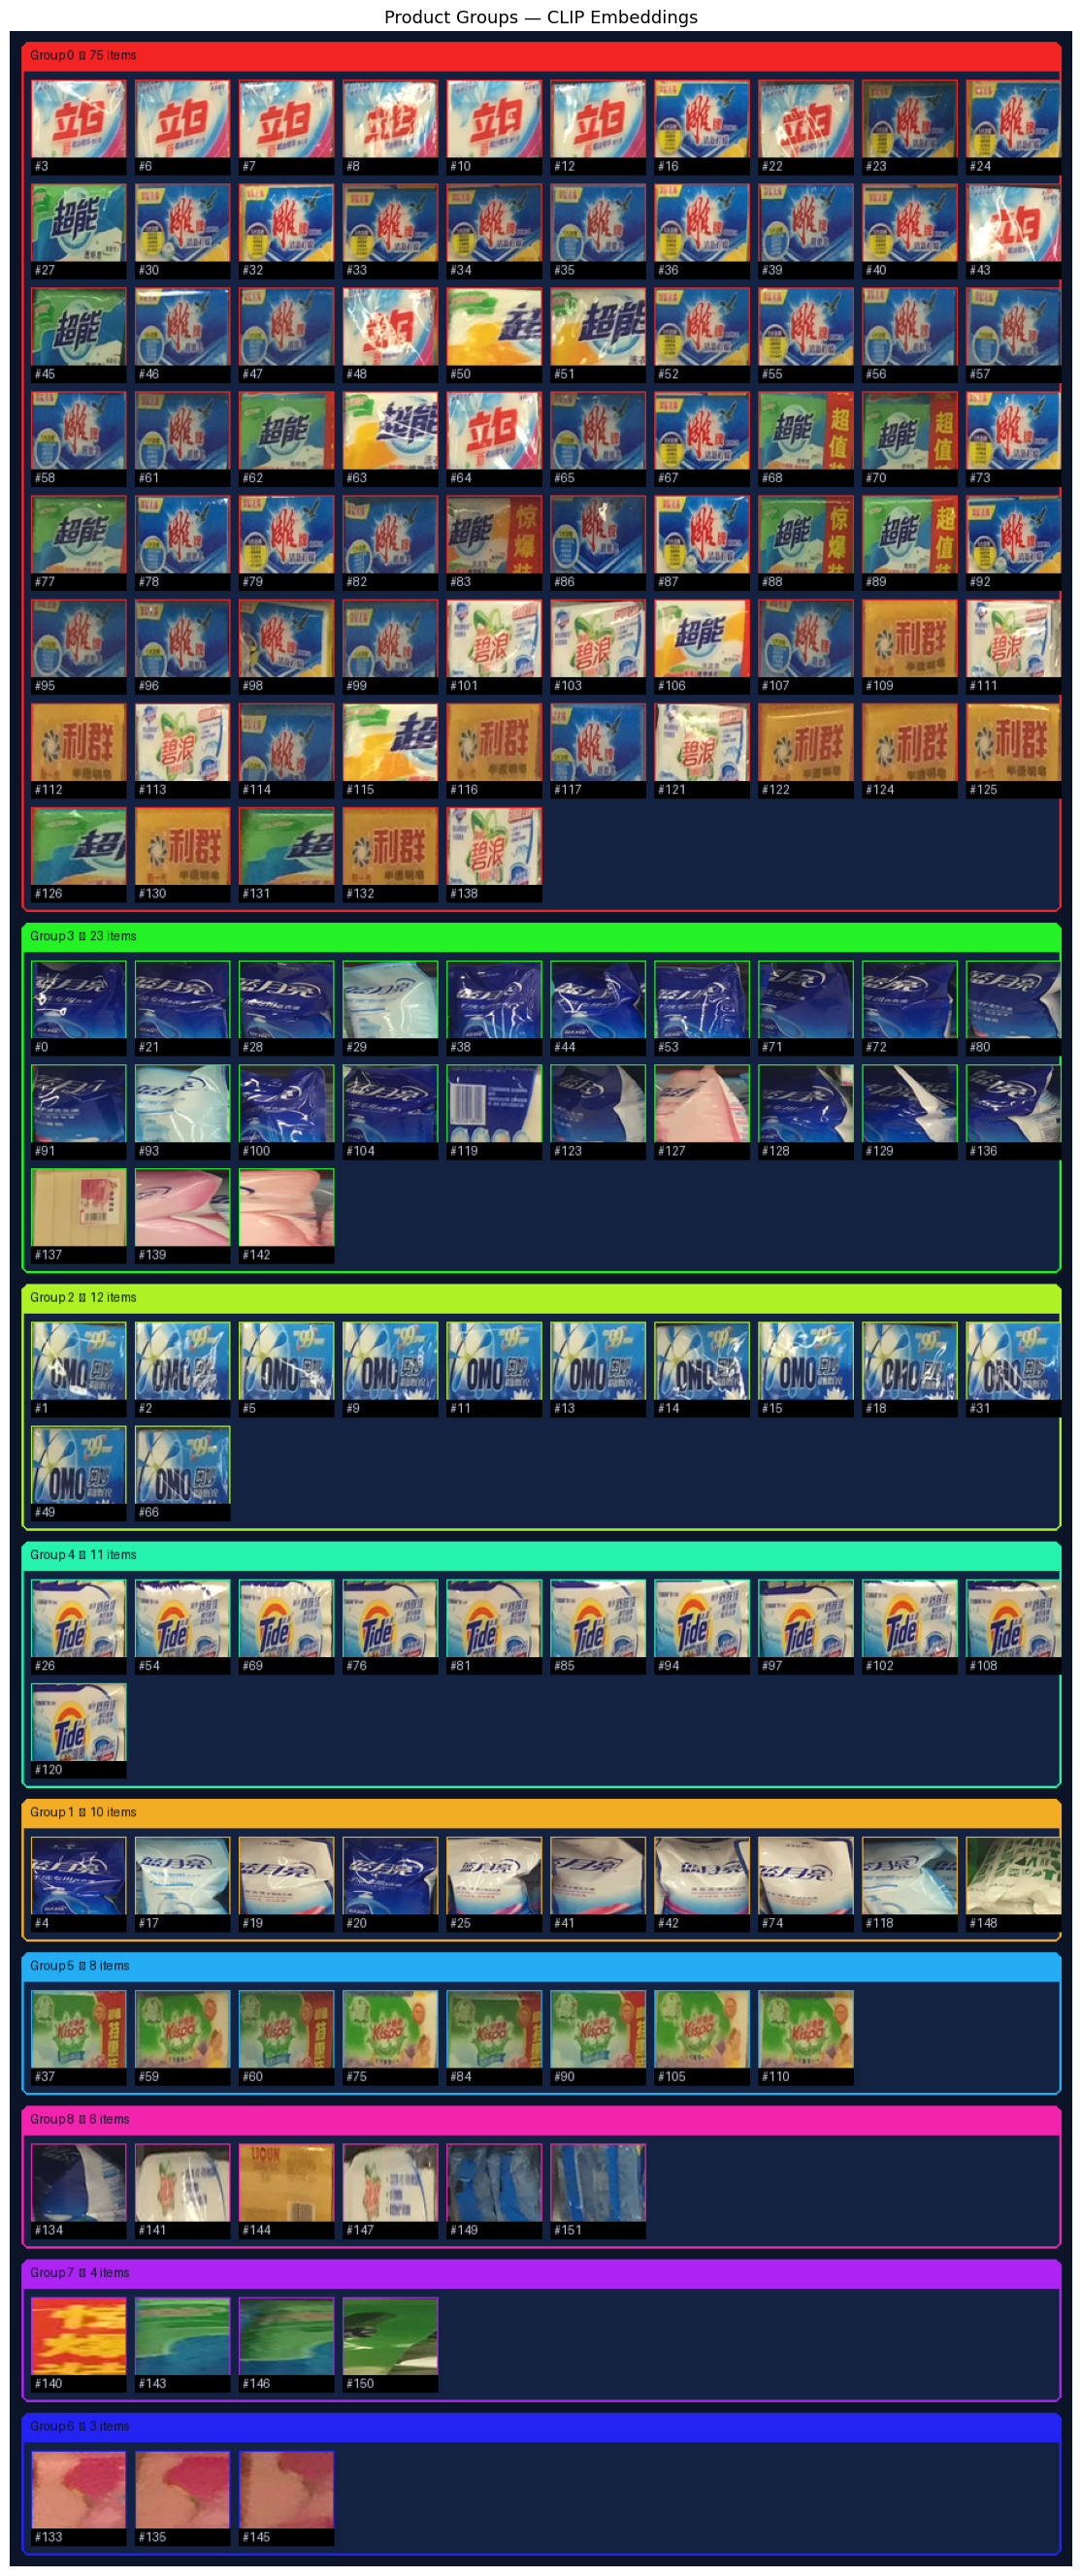

In [38]:
# ============================================================
# CELL 11 - Group gallery (crops organized by group)
# ============================================================
THUMB_W, THUMB_H = 80, 80
PADDING          = 8
HEADER_H         = 24
MARGIN           = 10
MAX_PER_ROW      = 10

# organize crops by group
groups = {}
for i, (crop, label) in enumerate(zip(crops, labels)):
    groups.setdefault(label, []).append((i, crop))

sorted_groups = sorted(groups.items(), key=lambda x: -len(x[1]))

def calc_group_h(n):
    rows = math.ceil(n / MAX_PER_ROW)
    return HEADER_H + rows * (THUMB_H + PADDING) + PADDING

total_h  = MARGIN + sum(calc_group_h(len(v)) + MARGIN for _, v in sorted_groups)
canvas_w = MARGIN + MAX_PER_ROW * (THUMB_W + PADDING) + MARGIN

canvas   = Image.new("RGB", (canvas_w, total_h), (12, 20, 40))
draw_c   = ImageDraw.Draw(canvas)

try:
    fnt_h = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 12)
    fnt_s = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 9)
except:
    fnt_h = fnt_s = ImageFont.load_default()

cursor_y = MARGIN
for gid, items in sorted_groups:
    color = group_color.get(gid, (150,150,150))
    gh    = calc_group_h(len(items))

    draw_c.rounded_rectangle(
        [MARGIN, cursor_y, canvas_w-MARGIN, cursor_y+gh],
        radius=6, fill=(20,34,65), outline=color, width=2
    )
    draw_c.rounded_rectangle(
        [MARGIN, cursor_y, canvas_w-MARGIN, cursor_y+HEADER_H],
        radius=6, fill=color
    )
    draw_c.rectangle(
        [MARGIN, cursor_y+HEADER_H//2, canvas_w-MARGIN, cursor_y+HEADER_H],
        fill=color
    )
    label_txt = f"Group {gid}  —  {len(items)} items" if gid != -1 else f"Unmatched  —  {len(items)} items"
    draw_c.text((MARGIN+8, cursor_y+5), label_txt, font=fnt_h, fill=(10,18,35))

    for idx, (orig_idx, crop) in enumerate(items):
        col = idx % MAX_PER_ROW
        row = idx // MAX_PER_ROW
        tx  = MARGIN + PADDING + col*(THUMB_W+PADDING)
        ty  = cursor_y + HEADER_H + PADDING + row*(THUMB_H+PADDING)

        thumb = Image.fromarray(crop).resize((THUMB_W, THUMB_H), Image.LANCZOS)
        canvas.paste(thumb, (tx, ty))
        draw_c.rectangle([tx, ty, tx+THUMB_W, ty+THUMB_H], outline=color, width=1)
        draw_c.rectangle([tx, ty+THUMB_H-14, tx+THUMB_W, ty+THUMB_H], fill=(0,0,0))
        draw_c.text((tx+3, ty+THUMB_H-13), f"#{orig_idx}", font=fnt_s, fill=(200,210,230))

    cursor_y += gh + MARGIN

plt.figure(figsize=(canvas_w/80, max(total_h/80, 4)))
plt.imshow(np.array(canvas))
plt.title("Product Groups — CLIP Embeddings", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# Assign unmatched crops to nearest group
# ============================================================

def assign_unmatched(embeddings, labels, sim_matrix):
    labels = labels.copy()
    
    # get valid group ids (not -1)
    group_ids = [l for l in labels if l != -1]
    
    if not group_ids:
        print("No groups found at all — lower EPS first")
        return labels
    
    unique_groups = list(set(group_ids))
    
    # for each unmatched crop, find its most similar matched crop
    for i, label in enumerate(labels):
        if label != -1:
            continue  # already in a group
        
        best_group = None
        best_sim   = -1
        
        for j, other_label in enumerate(labels):
            if other_label == -1 or i == j:
                continue
            sim = float(sim_matrix[i][j])
            if sim > best_sim:
                best_sim   = sim
                best_group = other_label
        
        labels[i] = best_group
        print(f"  Crop #{i} → Group {best_group} (similarity: {best_sim:.3f})")
    
    return labels

print("Assigning unmatched crops to nearest group...")
labels_filled = assign_unmatched(embeddings, labels, sim_matrix)

# summary
group_sizes_filled = {}
for l in labels_filled:
    group_sizes_filled[l] = group_sizes_filled.get(l, 0) + 1

print(f"\nBefore: {list(labels).count(-1)} unmatched")
print(f"After:  {list(labels_filled).count(-1)} unmatched")
print(f"\nGroup sizes after fill:")
for gid, size in sorted(group_sizes_filled.items(), key=lambda x: -x[1]):
    print(f"  Group {gid}: {size} items")

Assigning unmatched crops to nearest group...
  Crop #0 → Group 3 (similarity: 0.928)
  Crop #1 → Group 2 (similarity: 0.878)
  Crop #2 → Group 2 (similarity: 0.861)
  Crop #5 → Group 2 (similarity: 0.908)
  Crop #8 → Group 0 (similarity: 0.878)
  Crop #14 → Group 2 (similarity: 0.849)
  Crop #18 → Group 2 (similarity: 0.842)
  Crop #22 → Group 0 (similarity: 0.894)
  Crop #25 → Group 1 (similarity: 0.912)
  Crop #28 → Group 3 (similarity: 0.927)
  Crop #29 → Group 3 (similarity: 0.855)
  Crop #31 → Group 2 (similarity: 0.897)
  Crop #36 → Group 0 (similarity: 0.921)
  Crop #37 → Group 5 (similarity: 0.918)
  Crop #38 → Group 3 (similarity: 0.923)
  Crop #42 → Group 1 (similarity: 0.913)
  Crop #43 → Group 0 (similarity: 0.929)
  Crop #44 → Group 3 (similarity: 0.923)
  Crop #50 → Group 0 (similarity: 0.874)
  Crop #60 → Group 5 (similarity: 0.926)
  Crop #66 → Group 2 (similarity: 0.882)
  Crop #76 → Group 4 (similarity: 0.928)
  Crop #77 → Group 0 (similarity: 0.928)
  Crop #80 → Gro

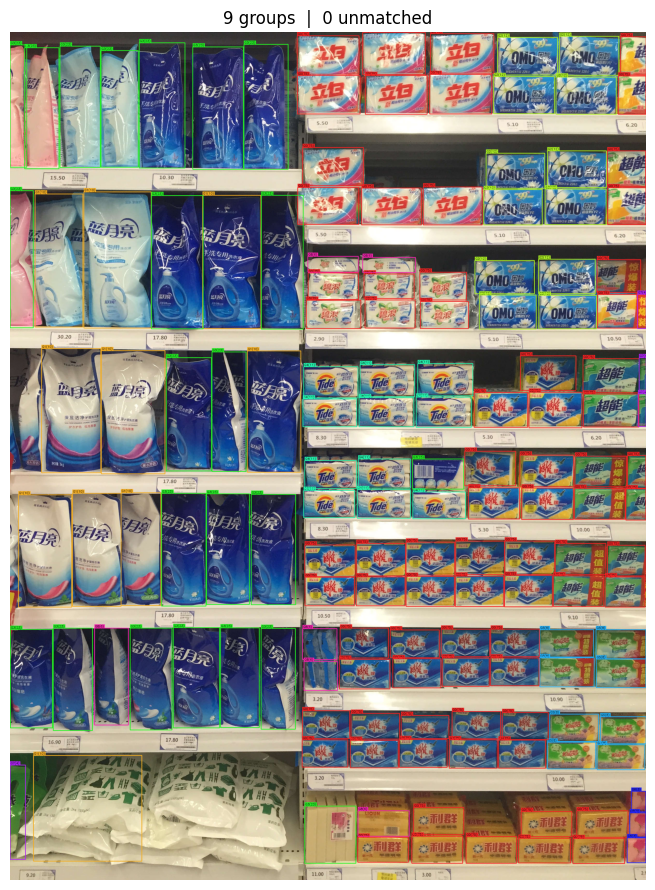

In [37]:
# ============================================================
# Visualize with filled groups
# ============================================================

# update labels and group_sizes to use filled version
labels      = labels_filled
group_sizes = group_sizes_filled

# reuse your existing Cell 10 visualization
n_groups    = len(set(labels))
group_color = {gid: hsv_color(i, n_groups)
               for i, gid in enumerate(set(labels))}

output = img_rgb.copy()
for box, label in zip(valid_boxes, labels):
    x1, y1, x2, y2 = box
    color = group_color[label]
    count = group_sizes.get(label, 1)

    cv2.rectangle(output, (x1,y1), (x2,y2), color, 2)

    tag = f"G{label}({count})"
    (tw, th), _ = cv2.getTextSize(tag, cv2.FONT_HERSHEY_SIMPLEX, 0.38, 1)
    cv2.rectangle(output, (x1, y1-th-5), (x1+tw+4, y1), color, -1)
    cv2.putText(output, tag, (x1+2, y1-3),
                cv2.FONT_HERSHEY_SIMPLEX, 0.38, (10,10,10), 1)

plt.figure(figsize=(18,9))
plt.imshow(output)
plt.title(f"{n_groups} groups  |  0 unmatched")
plt.axis("off")
plt.tight_layout()
plt.show()

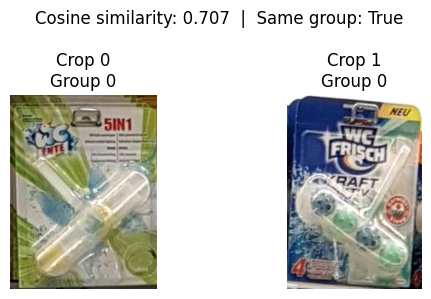

Similarity score: 0.707
Interpretation:   somewhat similar


In [14]:
# ============================================================
# CELL 12 - Check similarity between any two crops
# ============================================================
CROP_A = 0  # change these
CROP_B = 1

sim = float(sim_matrix[CROP_A][CROP_B])
same_group = labels[CROP_A] == labels[CROP_B]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(crops[CROP_A]); axes[0].set_title(f"Crop {CROP_A}\nGroup {labels[CROP_A]}"); axes[0].axis("off")
axes[1].imshow(crops[CROP_B]); axes[1].set_title(f"Crop {CROP_B}\nGroup {labels[CROP_B]}"); axes[1].axis("off")
plt.suptitle(f"Cosine similarity: {sim:.3f}  |  Same group: {same_group}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Similarity score: {sim:.3f}")
print(f"Interpretation:   {'very similar' if sim > 0.85 else 'somewhat similar' if sim > 0.70 else 'different'}")

In [15]:
# ============================================================
# CELL 13 - Tune EPS if grouping looks wrong
#
# Products splitting into too many groups → raise EPS
# Different products merging together    → lower EPS
# ============================================================
EPS = 0.30  # ← adjust this

clustering  = DBSCAN(eps=EPS, min_samples=2, metric="cosine").fit(embeddings)
labels      = clustering.labels_
group_sizes = {}
for l in labels:
    if l != -1:
        group_sizes[l] = group_sizes.get(l, 0) + 1

n_groups = len(set(l for l in labels if l != -1))
n_noise  = list(labels).count(-1)
print(f"EPS={EPS}  →  Groups: {n_groups}  |  Unmatched: {n_noise}")
print("Re-run Cell 10 and 11 to visualize with new grouping")

EPS=0.3  →  Groups: 1  |  Unmatched: 1
Re-run Cell 10 and 11 to visualize with new grouping


Total crop pairs:  10296
Min similarity:    0.366
Max similarity:    0.967
Mean similarity:   0.702
Median similarity: 0.704


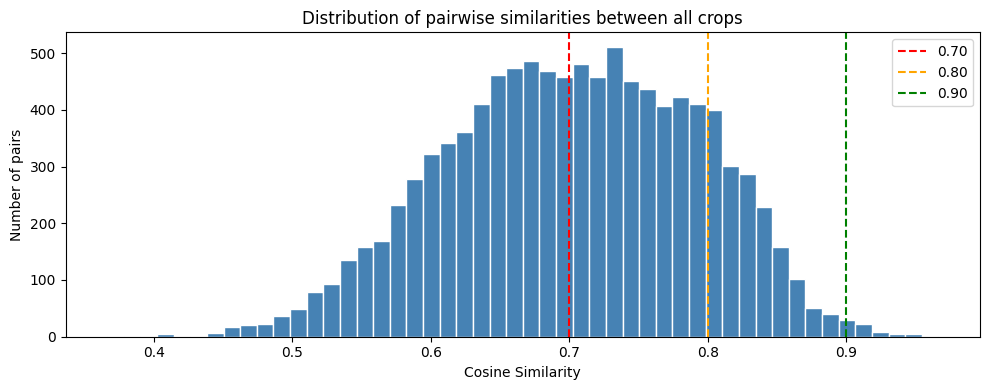

In [16]:
# ============================================================
# Run this first — understand your similarity distribution
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Get all pairwise similarities (excluding diagonal)
n = len(embeddings)
all_sims = []
for i in range(n):
    for j in range(i+1, n):
        all_sims.append(float(sim_matrix[i][j]))

all_sims = np.array(all_sims)

print(f"Total crop pairs:  {len(all_sims)}")
print(f"Min similarity:    {all_sims.min():.3f}")
print(f"Max similarity:    {all_sims.max():.3f}")
print(f"Mean similarity:   {all_sims.mean():.3f}")
print(f"Median similarity: {np.median(all_sims):.3f}")

# Histogram
plt.figure(figsize=(10, 4))
plt.hist(all_sims, bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of pairs")
plt.title("Distribution of pairwise similarities between all crops")
plt.axvline(0.70, color="red",    linestyle="--", label="0.70")
plt.axvline(0.80, color="orange", linestyle="--", label="0.80")
plt.axvline(0.90, color="green",  linestyle="--", label="0.90")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Try different EPS values and see which makes sense
# ============================================================
from sklearn.cluster import DBSCAN

for eps in [0.05, 0.10, 0.15, 0.20, 0.25]:
    clustering  = DBSCAN(eps=eps, min_samples=2, metric="cosine").fit(embeddings)
    labels_test = clustering.labels_
    n_groups    = len(set(l for l in labels_test if l != -1))
    n_noise     = list(labels_test).count(-1)
    print(f"EPS={eps}  →  Groups: {n_groups}  |  Unmatched (singletons): {n_noise}")

EPS=0.05  →  Groups: 2  |  Unmatched (singletons): 140
EPS=0.1  →  Groups: 12  |  Unmatched (singletons): 95
EPS=0.15  →  Groups: 7  |  Unmatched (singletons): 47
EPS=0.2  →  Groups: 4  |  Unmatched (singletons): 22
EPS=0.25  →  Groups: 2  |  Unmatched (singletons): 5
